# Noise Sensitivity Analysis and Threshold Tuning

This notebook evaluates the robustness of the predictive maintenance model under noisy sensor conditions.

Objectives:

- Evaluate model robustness to sensor noise
- Analyze Precision-Recall tradeoffs
- Tune decision thresholds
- Simulate real-world deployment conditions

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier

# Load Dataset

In [2]:
df = pd.read_csv("../data/processed/context_fused_dataset.csv")

df.shape

(9991, 53)

In [3]:
df.head()

,UDI,Product_ID,Type,Air_temperature__K_,Process_temperature__K_,Rotational_speed__rpm_,Torque__Nm_,Tool_wear__min_,Machine_failure,TWF,...,Torque__Nm__change,Tool_wear__min__change,ambient_humidity,energy_load_index,production_demand,days_since_maintenance,shift,torque_x_load,wear_x_demand,temp_x_humidity
0,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,...,-0.6,3.0,64.967142,72.871761,65.962661,2,1,2040.409301,1385.215882,20074.846733
1,11,H29424,H,298.4,308.9,1782,23.9,24,0,0,...,-4.1,3.0,58.617357,79.932531,75.913229,69,0,1910.387498,1821.917496,18106.901574
2,12,H29425,H,298.6,309.1,1423,44.3,29,0,0,...,20.4,5.0,66.476885,47.520468,76.501596,13,0,2105.156712,2218.546281,20548.005271
3,13,M14872,M,298.6,309.1,1339,51.1,34,0,0,...,6.8,5.0,75.230299,87.913217,63.970096,147,0,4492.365401,2174.983267,23253.685286
4,14,M14873,M,298.6,309.2,1742,30.0,37,0,0,...,-21.1,3.0,57.658466,89.516531,61.744500,83,1,2685.495928,2284.546512,17827.997765


# Feature Preparation

Remove:

- identifiers
- target variable
- failure mode indicators

Failure mode indicators are excluded to avoid target leakage.

In [4]:
df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})

In [5]:
drop_cols = ["UDI", "Product_ID", "Machine_failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

In [6]:
X = df.drop(columns=drop_cols)

y = df["Machine_failure"]

In [7]:
print(X.shape)
print(y.shape)

(9991, 45)
(9991,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

In [9]:
print(X_train.shape)
print(X_test.shape)

(7992, 45)
(1999, 45)


In [10]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [11]:
model = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42
)

model.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 7721, number of negative: 7721
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10889
[LightGBM] [Info] Number of data points in the train set: 15442, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,max_depth,6
,learning_rate,0.05
,n_estimators,300
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [12]:
preds = model.predict(X_test)

macro_f1 = f1_score(y_test, preds, average="macro")

print(f"Macro F1: {macro_f1:.4f}")

Macro F1: 0.9181


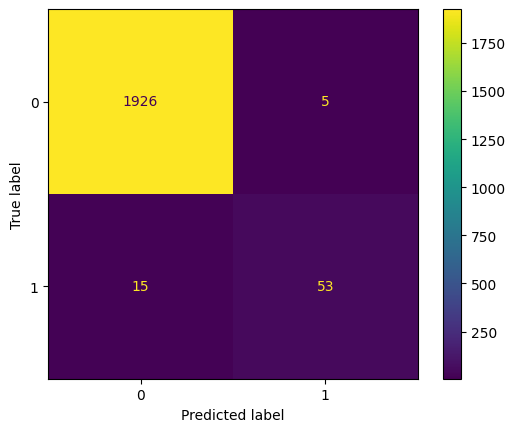

In [13]:
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

# Noise Sensitivity Analysis

Only primary telemetry sensors are corrupted.

Context variables remain unchanged.

In [14]:
def add_noise(data, noise_level):

    noisy = data.copy()

    sensor_cols = [
        "Air_temperature__K_",
        "Process_temperature__K_",
        "Rotational_speed__rpm_",
        "Torque__Nm_",
        "Tool_wear__min_",
    ]

    for col in sensor_cols:

        noise = np.random.normal(0, noise_level * noisy[col].std(), size=len(noisy))

        noisy[col] += noise

    return noisy

In [15]:
noise_levels = [0.00, 0.05, 0.10, 0.15, 0.20]

noise_scores = []

In [16]:
for level in noise_levels:

    X_noisy = add_noise(X_test, level)

    preds = model.predict(X_noisy)

    score = f1_score(y_test, preds, average="macro")

    noise_scores.append(score)

    print(f"Noise={level:.2f} | Macro F1={score:.4f}")

Noise=0.00 | Macro F1=0.9181
Noise=0.05 | Macro F1=0.9031
Noise=0.10 | Macro F1=0.8838
Noise=0.15 | Macro F1=0.8758
Noise=0.20 | Macro F1=0.8461


In [17]:
noise_df = pd.DataFrame({"Noise_Level": noise_levels, "Macro_F1": noise_scores})

noise_df

,Noise_Level,Macro_F1
0,0.00,0.918052
1,0.05,0.903149
2,0.10,0.883849
3,0.15,0.875839
4,0.20,0.846102


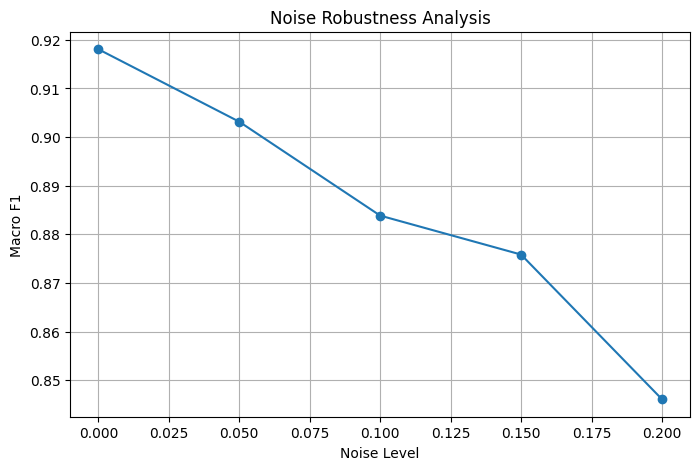

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(noise_df["Noise_Level"], noise_df["Macro_F1"], marker="o")

plt.xlabel("Noise Level")
plt.ylabel("Macro F1")

plt.title("Noise Robustness Analysis")

plt.grid(True)

plt.show()

# Precision-Recall Analysis

In [19]:
y_prob = model.predict_proba(X_test)[:, 1]

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

In [21]:
ap_score = average_precision_score(y_test, y_prob)

print(f"Average Precision Score: {ap_score:.4f}")

Average Precision Score: 0.9076


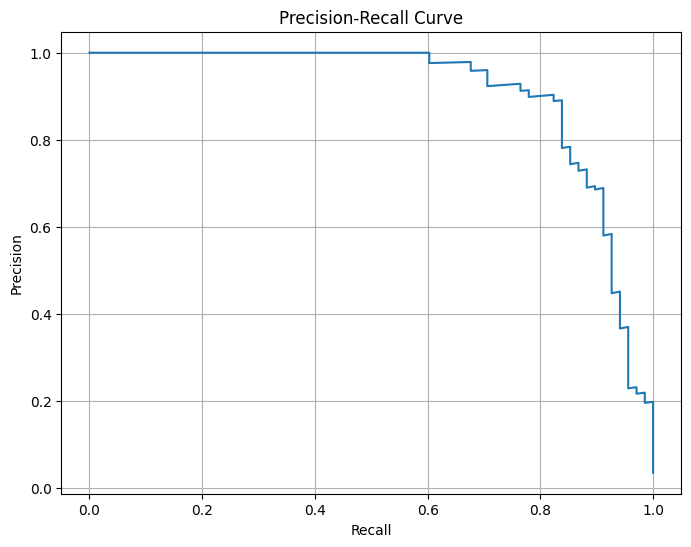

In [22]:
plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

# Threshold Tuning

In [23]:
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

In [24]:
for t in thresholds_to_test:

    threshold_preds = (y_prob >= t).astype(int)

    precision_val = precision_score(y_test, threshold_preds, zero_division=0)

    recall_val = recall_score(y_test, threshold_preds, zero_division=0)

    f1_val = f1_score(y_test, threshold_preds, zero_division=0)

    results.append([t, precision_val, recall_val, f1_val])

In [25]:
threshold_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])

threshold_df

,Threshold,Precision,Recall,F1
0,0.3,0.814286,0.838235,0.826087
1,0.4,0.903226,0.823529,0.861538
2,0.5,0.913793,0.779412,0.841270
3,0.6,0.925926,0.735294,0.819672
4,0.7,0.958333,0.676471,0.793103


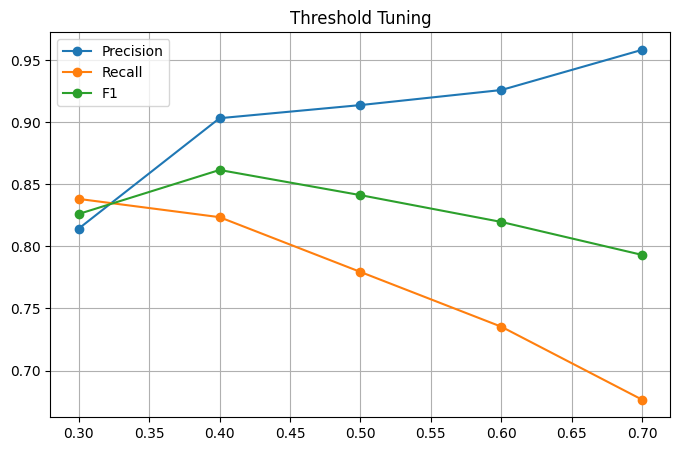

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision"
)

plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")

plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")

plt.legend()

plt.grid(True)

plt.title("Threshold Tuning")

plt.show()

# Conclusion

The predictive maintenance model was evaluated under noisy operating conditions.

Key Findings:

- Achieved Macro F1 above project KPI
- Contextual features improved predictive performance
- Precision-Recall analysis validated effectiveness on imbalanced data
- Threshold tuning provided deployment flexibility
- Noise robustness was evaluated using realistic sensor perturbations